In [17]:
from explore_import import  *
import ionbot_preprocess as io
import data_preprocess as dt
import hpp_checker as hpp
import data_preprocess as dt
import pyteomics.auxiliary as aux
import ast
import tpp_preprocess as tpp

warnings.simplefilter(action='ignore', category=FutureWarning)

In [18]:
project_palette={"canon":"orangered","trembl":"yellowgreen","openprot":"cornflowerblue"}
proteins_palette={"Canonical":"orangered","Non-canonical":"cornflowerblue","Reference isoforms":"yellowgreen","Novel isoforms":"gold"}
project_palette2={"canon":"orangered","trembl":"yellowgreen","openprot":"cornflowerblue",
                "Canon_unique":"salmon", "NonCanon_unique":"skyblue", "Shared":"darkkhaki",
                "Canon":"firebrick","Noncanon":"steelblue","TPP_canon":"lightcoral","TPP_trembl":"greenyellow","TPP_openprot":"paleturquoise",
                  "ionbot_canon":"orangered","ionbot_trembl":"yellowgreen","ionbot_openprot":"cornflowerblue",
                 "TPP_canon_unique":"chocolate",
                  "TPP_canon_unique_shared_in_class":"saddlebrown",
                  "TPP_noncanon_unique":"plum",
                  "TPP_noncanon_unique_shared_in_class":"orchid",
                  "TPP_shared":"tan",
                  "ionbot_canon_unique":"salmon",
                  "ionbot_canon_unique_shared_in_class":"rosybrown",
                  "ionbot_noncanon_unique":"skyblue",
                  "ionbot_noncanon_unique_shared_in_class":"mediumturquoise",
                  "ionbot_shared":"darkkhaki",
                 "ionbot_canon_unique_OnlyMod":"firebrick",
                 "ionbot_canon_unique_OnlyUnmod":"indianred",
                 "ionbot_canon_unique_Both":"lightcoral",
                 "ionbot_noncanon_unique_OnlyMod":"royalblue",
                 "ionbot_noncanon_unique_OnlyUnmod":"dodgerblue",
                 "ionbot_noncanon_unique_Both":"lightblue",
                 "ionbot_shared_OnlyMod":"olivedrab",
                 "ionbot_shared_OnlyUnmod":"olive",
                 "ionbot_shared_Both":"darkseagreen",}

In [19]:
peptide_classes={"NonCanon_unique":["unique_to_Noncanon",'shared_in_Noncanon'],
                "Canon_unique":["unique_to_Canon",'shared_in_Canon'],
                "Shared":['shared_btw_can_noncan']}

In [20]:
#load number of spectra in each mgf file

mgfspectraN_datasets=pickle.load(open('./../../../junk/mgfspectraN_datasets.pickle', 'rb'))

#as tpp does not record spectra file (but merged, input), then add up corresponding merged files n of spectra

#PXD014258
mgfspectraN_datasets['PXD014258.v0.11.4']={f"{i}.mgf":np.sum([mgfspectraN_datasets['PXD014258.v0.11.4'][f"{i}{j}.RAW.mgf"] for j in range(1,6)]) 
     if "BT474" not in i 
    else np.sum([mgfspectraN_datasets['PXD014258.v0.11.4'][f"{i}_{j}.RAW.mgf"] for j in range(1,6)])
     for i in ["ESC-HF-Sample-BT474","ESC-HF-SampleHela","ESC-HF-Sample-MCF"]
}
del mgfspectraN_datasets['PXD003594.v0.11.4']
# trim mgf
tmp = mgfspectraN_datasets.copy()
for _, d in tmp.items():
    for key in list(d.keys()):
        mgfspectraN_datasets[_][key[:-4]] = mgfspectraN_datasets[_].pop(key)
# trim .v0.11.4
for _, d in tmp.items():
    mgfspectraN_datasets[_[:-8]] = mgfspectraN_datasets.pop(_)
#trim ESC-HF- in PXD014258
tmp = mgfspectraN_datasets.copy()
for _, d in tmp.items():
    if _ == 'PXD014258':
        for key in list(d.keys()):
            mgfspectraN_datasets[_][key[7:]] = mgfspectraN_datasets[_].pop(key)

In [21]:
# GLOBAL VARS
PIPELINE = 'ionbot_open'
PIPELINE_LW = PIPELINE.lower()

In [22]:
#base directories

root="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery"
processed_dir=f"{root}/oui-discovery-vv-data/processed/20251015-oui-discovery-ionbot-results"
# get processed files
processed_paths=dt.list_files(processed_dir)
# leave only non-entrapment and open search, only search files
tmp = processed_paths.copy()
for parent, files in processed_paths.items():
    if '-closed' in parent or '-entrap' in parent:
        del tmp[parent]
        continue
    if not any( 'group-walk-output.csv' in f for f in files):
        del tmp[parent]
processed_paths = tmp

# where to save pickles
results_dir = f"{root}/oui-discovery-vv-data/pickles"

20251015-oui-discovery-ionbot-results/
    PXD005833.v0.11.4/
        openprot-x-trembl-filt-global-outerjoin.csv
        PXD005833-opensearch-x-closedsearch-filt-global.csv.gz
        Metadata_PXD005833.v0.11.4-openprot.txt
        ID-rate-df-filt-hybrid.csv
        ID-rate-df-filt-False.csv
        Metadata_PXD005833.v0.11.4-canon.txt
        Metadata_PXD005833.v0.11.4-trembl.txt
        PXD005833-opensearch-x-closedsearch-filt-global-outerjoin.csv.gz
        openprot-x-trembl-filt-global.csv
        ID-rate-df-filt-custom.csv
        ID-rate-df-filt-global.csv
        ID-rate-df-filt-groupwalk.csv
        PXD005833.v0.11.4-canon/
            PXD005833.v0.11.4-canon-combined-features.csv.gz
            combined-results-w-qvalues.csv.gz
            AM15-canon/
                ionbot.first.proteins.csv
                sample-protein-inference-input.pout
                group-walk-output-peptide-vv.csv
                ionbot.features.csv
                ionbot.first.csv
                

In [23]:
# save plots
plot_dir = f'{root}/oui-discovery-vv-plot/{PIPELINE_LW}'

### Load and filter

#### PSM - 1% Global FDR

In [24]:
psm_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output.csv': #-db
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            # from Enrico
            # fixes issue with some files being .RAW and other being .raw
            #data.spectrum_file = data.spectrum_file.apply(lambda x: x.split('.')[0])
            # in some mgf files the 'spectrum title' includes the file name, making the spectrum title unique.
            # when the file name is NOT included, spectrum titles are NOT unique, and this can mess up some analysis.
            #data.spectrum_title = data.spectrum_file + ':' + data.spectrum_title.apply(lambda x: x.split(':')[-1])
            psm_filt += [data]
psm_filt = pd.concat(psm_filt)
# NOTE: decoys are retained
psm_filt = psm_filt[(psm_filt['q.value'] < 0.01)&(psm_filt['isCanonical'] != 'Contam')]

# str to list
psm_filt['proteins'] = psm_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
psm_filt['isProteotypic'] = psm_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
psm_filt["peptide_class"]=psm_filt["proteins"].apply(tpp.classify_peptide_tpp)

/tmp/ipykernel_3845330/2595102683.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))
/tmp/ipykernel_3845330/2595102683.py:9: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(parent, file))


<Axes: title={'center': 'PSM count, 1% Global FDR'}, xlabel='dataset,search_database,spectrum_file'>

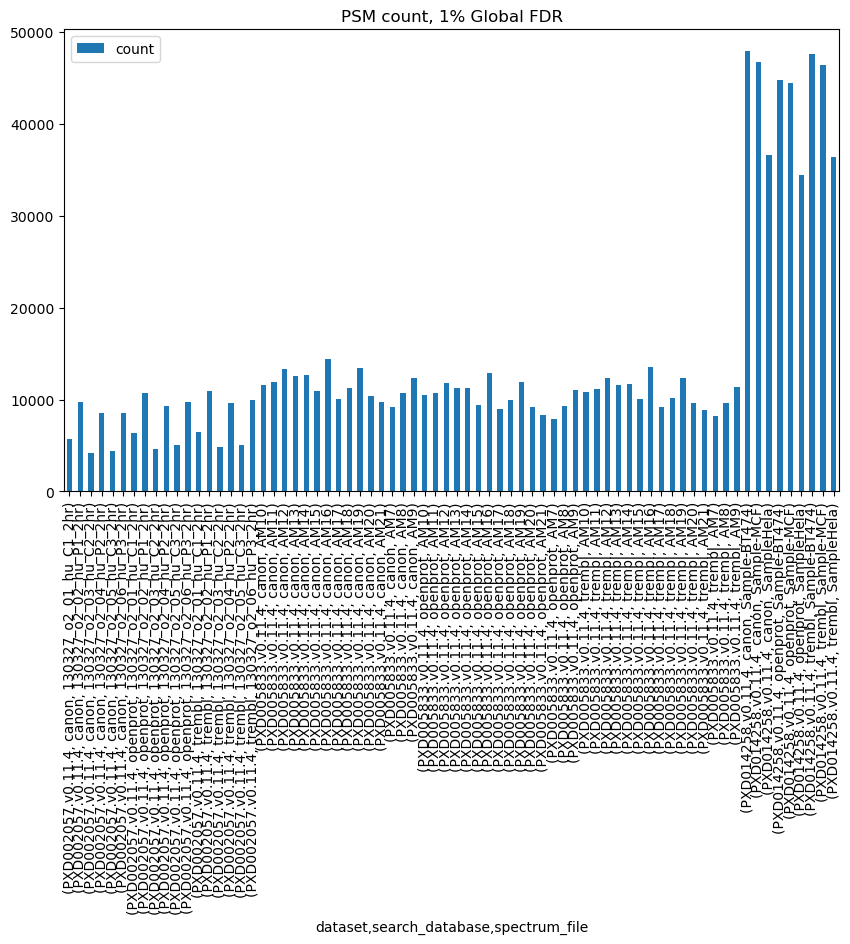

In [25]:
psm_filt[['dataset', 'search_database', 'spectrum_file']].value_counts().sort_index().to_frame().plot.bar(figsize=(10, 6), title='PSM count, 1% Global FDR')

#### Peptide - subset FDP-rank

In [26]:
pep_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'group-walk-output-peptide-vv.csv' :
            spectrum_file = '-'.join(parent.split('/')[-1].split('-')[:-1])
            search_database = parent.split('/')[-1].split('-')[-1]
            dataset = parent.split('/')[-2].split('-')[0]
            data = pd.read_csv(os.path.join(parent, file))
            data['spectrum_file'] = spectrum_file
            data['search_database'] = search_database
            data['dataset'] = dataset
            pep_filt += [data]
pep_filt = pd.concat(pep_filt)
# NOTE: only target peptides are left
pep_filt = pep_filt[(pep_filt['subset_max_rank'] == True)&(pep_filt['isCanonical'] != 'Contam')]

# str to list
#pep_filt['protein'] = pep_filt['protein'].apply(lambda x: ast.literal_eval(x))
pep_filt['proteins'] = pep_filt['proteins'].apply(lambda x: x.split(';'))
# indicate proteotypic peptides
pep_filt['isProteotypic'] = pep_filt['proteins'].apply(lambda x: len(x)==1)
# peptide class
pep_filt["peptide_class"]=pep_filt["proteins"].apply(tpp.classify_peptide_tpp)

In [27]:
# are some samples missing in peptide level due to filter? --yes

a = set(tuple(map(tuple, psm_filt[['dataset', 'search_database', 'spectrum_file']].drop_duplicates().values)))
b = set(tuple(map(tuple, pep_filt[['dataset', 'search_database', 'spectrum_file']].drop_duplicates().values)))
len(a) == len(a & b)

True

<Axes: title={'center': 'Peptide count, subset FDP-rank'}, xlabel='dataset,search_database,spectrum_file'>

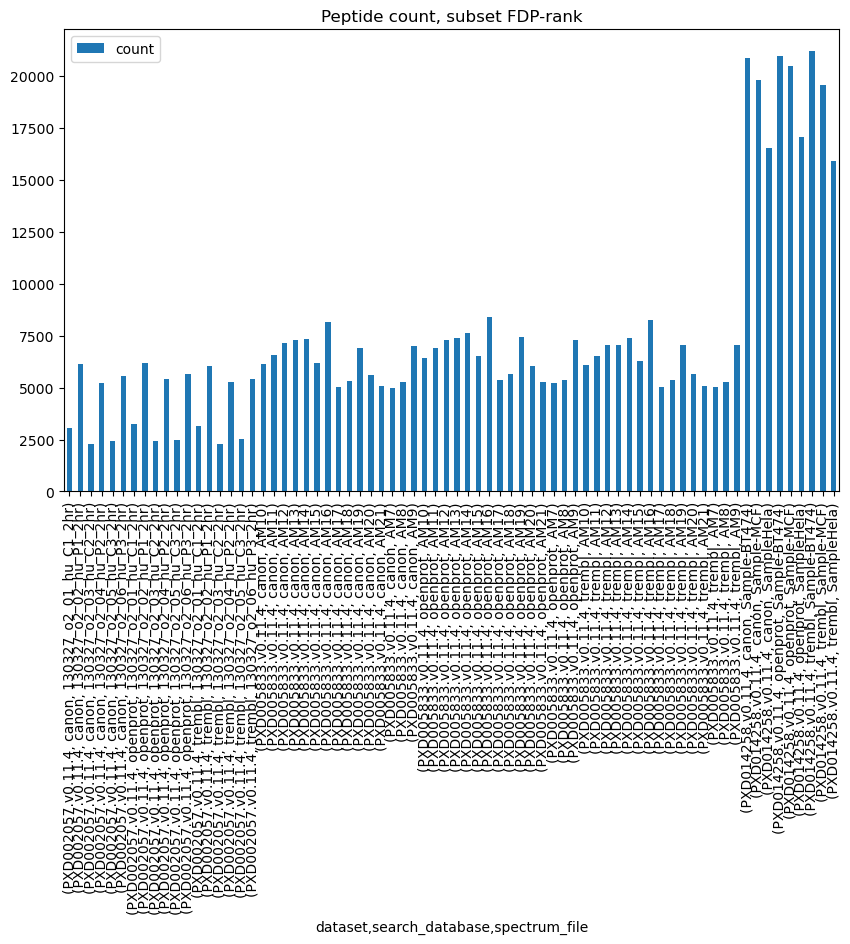

In [28]:
pep_filt[['dataset', 'search_database', 'spectrum_file']].value_counts().sort_index().to_frame().plot.bar(figsize=(10, 6), title='Peptide count, subset FDP-rank')

#### Protein level - add Non-canon w 1+ proteotipic peptide

In [29]:
def classify_leadprot(x):
    x=x.replace("decoy_","")
    if 'CONTAMINANT' in x.upper():
        return 'Contam'
    elif x.startswith('II_') or x.startswith('IP_'):
        return 'NonCanon'
        # Ensembl is canonical
    else:
        return 'Canon'
def is_peptide_canonical(x):
    '''x is the list of protein classes'''
    if np.array([_=='Contam' for _ in x]).any():
        return 'Contam'
    if np.array([_=='Canon' for _ in x]).any():
        return 'Canonical'
    return 'NonCanonical'

In [30]:
prot_filt = []
for parent, files in processed_paths.items():
    if ".ipynb_checkpoints" in parent: continue
    for file in files:
        if file == 'sample_protein_groups_Occam.csv': #-closed-db
            data = pd.read_csv(os.path.join(parent, file))
            prot_filt += [data]
prot_filt = pd.concat(prot_filt)
prot_filt["protein_classes"] = prot_filt.proteins.apply(lambda x: np.unique([classify_leadprot(_) for _ in x.split(',')]))
prot_filt["isCanonical"] = prot_filt.protein_classes.apply(is_peptide_canonical)

In [31]:
print('From protein inference',len(prot_filt))
# NOTE: it has no decoys and contaminants
prot_filt = prot_filt[(prot_filt['isCanonical'] == 'Canonical')] #remove non-canonical proteins 9including those with only shared peptides)
print('Canonical',len(prot_filt))

# Get noncanonical proteins with at least one proteotypic peptide
prot_noncanon = pep_filt[
    (pep_filt['search_database'] == 'openprot')&
    (pep_filt['isCanonical'] == 'NonCanonical')&
    (pep_filt['isProteotypic'] == True)
].sort_values('psm_score').drop_duplicates(['spectrum_file','database_peptide'],keep='first')
# select relevant columns
prot_noncanon = prot_noncanon[['proteins','database','psm_score','spectrum_file','dataset','search_database','is.decoy','q.value','protein_classes','isCanonical']]
#prot_noncanon['isModified'] = pd.NA
prot_noncanon['proteins'] = prot_noncanon['proteins'].apply(lambda x: ','.join(x))
prot_noncanon.columns = prot_filt.columns

# Uppend noncanonical to proteins set
prot_filt = pd.concat([prot_filt, prot_noncanon])
print('Canonical + Non-canonical',len(prot_filt))

# indicate groups and proteins with proteotypic peptides
prot_filt['level'] = prot_filt.proteins.apply(lambda x: "Group" if "," in x else "Singleton")

From protein inference 92763
Canonical 92074
Canonical + Non-canonical 93490


### Identification rate by search

In [32]:
id_rates = []
for (dataset, spectrum_file, search_database), df in psm_filt.groupby(['dataset', 'spectrum_file','search_database']):
    n_spec = mgfspectraN_datasets[dataset[:9]][spectrum_file]
    id_rate = len(df[df['database'] == 'T'])/n_spec
    id_rates += [[PIPELINE,dataset, spectrum_file, search_database, id_rate]]
id_rates = pd.DataFrame(id_rates, columns = ["pipeline","dataset","sample","database","value"])   
id_rates.to_pickle(f"{results_dir}/{PIPELINE_LW}_idrate_datasets_df.pkl")

In [33]:
#sns.stripplot(data=id_rates, x='database', y='value', hue='dataset')

### Identification rate by peptide class

In [34]:
id_rates_pepcl = []
for (dataset, spectrum_file, peptide_class), df in psm_filt[psm_filt['search_database'] == 'openprot'].groupby(['dataset', 'spectrum_file','peptide_class']):
    n_spec = mgfspectraN_datasets[dataset[:9]][spectrum_file]
    id_rate = len(df[df['database'] == 'T'])/n_spec
    id_rates_pepcl += [[PIPELINE,dataset, spectrum_file, peptide_class, id_rate]]
id_rates_pepcl = pd.DataFrame(id_rates_pepcl, columns = ["pipeline","dataset","sample","peptide_class","value"])  
id_rates_pepcl.to_pickle(f"{results_dir}/{PIPELINE_LW}_PEPCL_idrate_datasets_df.pkl")

In [35]:
#sns.stripplot(data=id_rates_pepcl, x='peptide_class', y='value', hue='dataset')

### Peptides' reproducability across datasets

In [36]:
# count of peptides in 1,2, 2+ samp per dataset and all datasets and per peptide_class

pep_repr = []
for (dataset, search_database, peptide_class), df in pep_filt.groupby(['dataset', 'search_database','peptide_class']):
    n_pep_per_samp = Counter(df['database_peptide'].value_counts())
    more_2 = sum(n_pep for n_samp, n_pep in n_pep_per_samp.items() if n_samp>2)
    pep_repr += [[PIPELINE, dataset, search_database, peptide_class, '1', n_pep_per_samp[1] ]]
    pep_repr += [[PIPELINE, dataset, search_database, peptide_class, '2', n_pep_per_samp[2] ]]
    pep_repr += [[PIPELINE, dataset, search_database, peptide_class, '2+', more_2 ]]
# across all datasets
for (search_database, peptide_class), df in pep_filt.groupby(['search_database','peptide_class']):
    n_pep_per_samp = Counter(df['database_peptide'].value_counts())
    more_2 = sum(n_pep for n_samp, n_pep in n_pep_per_samp.items() if n_samp>2)
    pep_repr += [[PIPELINE, 'all', search_database, peptide_class, '1', n_pep_per_samp[1] ]]
    pep_repr += [[PIPELINE, 'all', search_database, peptide_class, '2', n_pep_per_samp[2] ]]
    pep_repr += [[PIPELINE, 'all', search_database, peptide_class, '2+', more_2 ]]
pep_repr = pd.DataFrame(pep_repr, columns = ["pipeline","dataset","search_database","peptide_class","n_samp","value"]) 
pep_repr.to_pickle(f"{results_dir}/{PIPELINE_LW}_peptides_across_samples_PEP_df.pkl")

In [37]:
#sns.stripplot(data=pep_repr, x='peptide_class', y='value', hue='dataset')

### Number of PSMs per peptide class

In [38]:
psm_pepcl = []
bins = [[1],list(range(2,10+1)),list(range(10,10000))]
bins_i = [(i,b) for i, b in enumerate(bins)]
for (peptide, peptide_class), df in psm_filt[(psm_filt['search_database'] == 'openprot')&(psm_filt['database'] == 'T')].groupby(['database_peptide', 'peptide_class']):
    n_psm = len(df)
    b_i = [i for i,b in bins_i if n_psm in b][0]
    psm_pepcl += [[PIPELINE, peptide, peptide_class, n_psm, b_i]]
psm_pepcl = pd.DataFrame(psm_pepcl, columns = ["pipeline","peptide","peptide_class","psm_num","bin"]) 
psm_pepcl.to_pickle(f"{results_dir}/{PIPELINE_LW}_pepcl_psm_frq.pkl")

In [39]:
#sns.kdeplot(data=psm_pepcl,x='psm_num', hue='peptide_class')

In [40]:
#sns.barplot(data=psm_pepcl,x='bin',y='psm_num', hue='peptide_class')

### Number of proteins by search database

In [41]:
prot_db = []
for database, df in prot_filt.groupby('searchDB'):
    group_sing=df[df.level=="Singleton"]
    group_uplim=df[df.level=="Group"]
    singletons=set(group_sing.proteins.tolist())
    uplim=set([p for g in group_uplim.proteins.tolist() for p in g.split(",")])
    prot_db += [[PIPELINE, database, "singletons", len(singletons)]]
    prot_db += [[PIPELINE, database, "indistinguishable proteins",len(uplim-singletons)]]
prot_db = pd.DataFrame(prot_db, columns = ["pipeline","database","group","value"]) 
prot_db.to_pickle(f"{results_dir}/{PIPELINE_LW}_bysearch_proteins.pkl")

In [42]:
#sns.barplot(data=prot_db, y='value',x='database', hue='group')

### Proteins reproducability

In [43]:
def get_prot_repr(df,pipeline,dataset, search_database):
    prot_repr = []
    sing = df[df['level']=='Singleton']
    n_sing_per_samp = Counter(sing['proteins'].value_counts())
    more_2_sing = sum(n_pep for n_samp, n_pep in n_sing_per_samp.items() if n_samp>2)
    prot_repr += [[pipeline, dataset, search_database, 'singletons', '1', n_sing_per_samp[1] ]]
    prot_repr += [[pipeline, dataset, search_database, 'singletons', '2', n_sing_per_samp[2] ]]
    prot_repr += [[pipeline, dataset, search_database, 'singletons', '2+', more_2_sing ]]
    group = df[df['level']=='Group']
    group['proteins'] = group['proteins'].str.split(',')
    group = group.explode('proteins')
    uplim = group[~group['proteins'].isin(sing['proteins'].tolist())]
    uplim = uplim.drop_duplicates(['proteins','experiment']) # proteins from groups appear more than once
    n_uplim_per_samp = Counter(uplim['proteins'].value_counts())
    more_2_uplim = sum(n_pep for n_samp, n_pep in n_uplim_per_samp.items() if n_samp>2)
    prot_repr += [[pipeline, dataset, search_database, 'indistinguishable proteins', '1', n_uplim_per_samp[1] ]]
    prot_repr += [[pipeline, dataset, search_database, 'indistinguishable proteins', '2', n_uplim_per_samp[2] ]]
    prot_repr += [[pipeline, dataset, search_database, 'indistinguishable proteins', '2+', more_2_uplim ]]
    return prot_repr

In [44]:
# count of proteins in 1,2, 2+ samp per dataset and all datasets and per level

prot_repr = []
for (dataset, search_database), df in prot_filt.groupby(['PXD', 'searchDB',]):
    prot_repr += get_prot_repr(df, PIPELINE, dataset, search_database)
    
# across all datasets
for search_database, df in prot_filt.groupby('searchDB'):
    prot_repr += get_prot_repr(df, PIPELINE, 'all', search_database)
prot_repr = pd.DataFrame(prot_repr, columns = ["pipeline","dataset","search_database","level","n_samp","value"]) 
prot_repr.to_pickle(f"{results_dir}/{PIPELINE_LW}_prot_reproduce_PXD_{PIPELINE_LW}_protcl_counts.pkl")

/tmp/ipykernel_3845330/485010927.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['proteins'] = group['proteins'].str.split(',')
/tmp/ipykernel_3845330/485010927.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  group['proteins'] = group['proteins'].str.split(',')
/tmp/ipykernel_3845330/485010927.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [45]:
#for level, df in prot_repr.groupby('level'):
#    sns.barplot(data=df[df['dataset']!='all'],x='search_database',y='value',hue='n_samp')
#    plt.title(level)
#    plt.show()

### Number of proteins per protein class

In [46]:
prot_cls = []
for (search_database,isCanonical), df in prot_filt.groupby(['searchDB', 'isCanonical']):
    group_sing=df[df.level=="Singleton"]
    group_uplim=df[df.level=="Group"]
    singletons=set(group_sing.proteins.tolist())
    uplim=set([p for g in group_uplim.proteins.tolist() for p in g.split(",")])
    prot_cls += [[PIPELINE, search_database, isCanonical,"singletons", len(singletons)]]
    prot_cls += [[PIPELINE, search_database, isCanonical,"indistinguishable proteins", len(uplim-singletons)]]
prot_cls = pd.DataFrame(prot_cls,columns = ["pipeline","search","protein_class","group","value"])
prot_cls.to_pickle(f"{results_dir}/{PIPELINE_LW}_byprotclass_proteins.pkl")

In [47]:
#for level, df in prot_cls.groupby('group'):
#    sns.barplot(data=df, x='search',y='value',hue='protein_class')
#    plt.title(level)
#    plt.show()

### Number of peptides & PSMs per protein per protein class

In [48]:
# Deduplicate proteins, by sample
prot_filt_op = prot_filt[prot_filt['searchDB'] == 'openprot']
prot_filt_op['proteins'] = prot_filt_op['proteins'].str.split(',')
prot_filt_op = prot_filt_op.explode('proteins')
prot_filt_op = prot_filt_op.sort_values('level') # G->S
prot_filt_op = prot_filt_op.drop_duplicates('proteins',keep='last') #keep singleton mark if also part of group
# Deduplicate peptides by sample
pep_filt_op = pep_filt[pep_filt['search_database'] == 'openprot']
pep_filt_op = pep_filt_op.drop_duplicates('database_peptide',keep='first')
pep_filt_op = pep_filt_op.explode('proteins')
pep_filt_op = pep_filt_op[pep_filt_op['proteins'].isin(prot_filt_op['proteins'].tolist())] #select only peptides present on protein level
# PSM
psm_filt_op = psm_filt[psm_filt['search_database'] == 'openprot']
psm_filt_op = psm_filt_op.explode('proteins')
psm_filt_op = psm_filt_op[psm_filt_op['proteins'].isin(prot_filt_op['proteins'].tolist())] #select only PSM present on protein level

#NOTE each df has duplicated rows due to protein groups expansion

/tmp/ipykernel_3845330/1825217463.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prot_filt_op['proteins'] = prot_filt_op['proteins'].str.split(',')


In [49]:
len(prot_filt_op), len(pep_filt_op), len(psm_filt_op)

(33349, 279517, 2268645)

In [50]:
#merge peptide class
pep_per_prot = []
for (isCanonical, level), df in prot_filt_op.groupby(['isCanonical', 'level']):
   # Precompute peptide counts per protein once
    counts = pep_filt_op['proteins'].value_counts()
    result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
    result.columns = ['proteins','value']
    result['level'] = level
    result['protein_class'] = isCanonical
    pep_per_prot += [result]
pep_per_prot = pd.concat(pep_per_prot)
pep_per_prot.to_pickle(f"{results_dir}/{PIPELINE_LW}_pep_per_prot.pkl")

/tmp/ipykernel_3845330/3113863560.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
/tmp/ipykernel_3845330/3113863560.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
/tmp/ipyke

In [51]:
#sns.barplot(data=pep_per_prot, x='protein_class', y='value', hue='level')

In [52]:
#merge peptide class
psm_per_prot = []
for (isCanonical, level), df in prot_filt_op.groupby(['isCanonical', 'level']):
   # Precompute peptide counts per protein once
    counts = psm_filt_op['proteins'].value_counts()
    result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
    result.columns = ['proteins','value']
    result['level'] = level
    result['protein_class'] = isCanonical
    psm_per_prot += [result]
psm_per_prot = pd.concat(psm_per_prot)
psm_per_prot.to_pickle(f"{results_dir}/{PIPELINE_LW}_psm_per_prot.pkl")

/tmp/ipykernel_3845330/3016165328.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
/tmp/ipykernel_3845330/3016165328.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby('proteins', group_keys=False).apply(lambda x: counts.get(x.name, 0)).to_frame().reset_index()
/tmp/ipyke

In [53]:
#sns.barplot(data=psm_per_prot, x='protein_class', y='value', hue='level')

### Proteotypic peptides coverage

In [54]:
all_peptide_sequences=pickle.load(open('./../../../junk/all_peptide_sequences_OP_7302.pkl', 'rb'))
is_unique=pickle.load(open('./../../../junk/is_unique_OP_7302.pkl', 'rb'))

In [55]:
# Repeat protein for each protein in group

proteins_op = prot_filt_op.copy(deep=True)

In [56]:
#Load OpenProt database

OPfasta_file="/project/def-marie87/vvshazia/pride_reanalysis/CompOmics/oui-discovery/oui-discovery-vv-data/raw/msfragger_pride_reanalysis/concatenated-fastas/20241102-openprot-database_ionbot_db/concat.fasta"
input_file = open(OPfasta_file)
OPfasta = SeqIO.to_dict(SeqIO.parse(OPfasta_file, "fasta"))

In [57]:
prophet_filt_op=pep_filt_op.copy(deep=True)
#Drop PEPTIDE to same peptide and protein
prophet_filt_op.drop_duplicates(["database_peptide","proteins"],inplace=True,keep="first")
prophet_filt_op.reset_index(drop=True,inplace=True)

In [58]:
#Leave only proteotypic peptides
prophet_filt_op=prophet_filt_op[prophet_filt_op.isProteotypic==True]

In [59]:
#get the peptides' positions in proteins

count_var=0
prophet_filt_op["peptide_position"]='nan'
for i,row in prophet_filt_op.iterrows():
    peptide=row["database_peptide"]; prot=row["proteins"]
    #prot_seq=str(OPfasta[f"op|{prot}|TX=9606"].seq)
    prot_seq=str(OPfasta[prot].seq)
    pos=hpp.get_pep_positions(prot_seq,peptide)
    if len(pos)>1: pos=[pos[0]] #take first occurance in protein
    if len(pos)==0: #if didnt find peptide in protein
        # try L->I
        peptide = peptide.replace('L','I')
        prot_seq=str(OPfasta[prot].seq)
        pos=hpp.get_pep_positions(prot_seq,peptide)
        if len(pos)>1: pos=[pos[0]]
        if len(pos)==0:
            count_var+=1;  pos=[np.nan]
            print(peptide,prot,prot_seq)
    prophet_filt_op.at[i,"peptide_position"]=[[pos[0]]]#pd.Series([pos[0]]).values[0]
#are their peptides with SAAVs introduced 
print(count_var)
#drop peptides with SAAVs introduced by Comet
prophet_filt_op=prophet_filt_op[~prophet_filt_op.peptide_position.isna()]

0


In [60]:
#Select proteotypic peptides from in silico digested database

all_peptide_sequences_identunique={}
for prot in set(prophet_filt_op['proteins'].tolist()):
    try:
        peps=all_peptide_sequences[f"op|{prot}|TX=9606"]
        peps_unique=[is_unique[p]  for p in peps]
        peps_unique=np.array(peps)[peps_unique]
        all_peptide_sequences_identunique[prot]=peps_unique
    except KeyError:  #skip contominants
        continue

In [61]:
#Get positions of in-silico proteotypic peptides in proteins

all_peptide_sequences_identunique_pos={}
for prot,uniquepeps in all_peptide_sequences_identunique.items():
    group=pd.DataFrame({"database_peptide":list(uniquepeps),"peptide_position":[np.nan]*len(uniquepeps)})
    #prot_seq=str(OPfasta[f"op|{prot}|TX=9606"].seq)
    prot_seq=str(OPfasta[prot].seq)
    #in this fasta all L are replaced to I, so correct for this
    uniquepeps=[pep.replace("L","I") for pep in uniquepeps]
    uniquepeps_pos=[]
    for pep in uniquepeps:
        pos=hpp.get_pep_positions(prot_seq,pep)
        if len(pos)>1: pos=[pos[0]]
        uniquepeps_pos=uniquepeps_pos+pos
    group["peptide_position"]=uniquepeps_pos
    all_peptide_sequences_identunique_pos[prot]=group

In [62]:
#Add positions data of peptides, identified 

all_peptide_sequences_identunique_pos_wident={}
for prot,uniquepeps_df in all_peptide_sequences_identunique_pos.items():
    ident_df=prophet_filt_op.groupby("proteins").get_group(prot)
    all_peptide_sequences_identunique_pos_wident[prot]=uniquepeps_df.merge(ident_df[["database_peptide","peptide_position"]],how="outer",on="database_peptide")

In [63]:
def flatten_tuples(obj):
    """Recursively flatten nested lists of tuples."""
    if isinstance(obj, list):
        result = []
        for item in obj:
            result.extend(flatten_tuples(item))
        return result
    elif isinstance(obj, tuple):
        return [obj]
    else:
        return []

In [64]:
#Coverage

unique_peptide_aa_coverege={}
dict_deepcopy=copy.deepcopy(all_peptide_sequences_identunique_pos_wident)
for prot_i,uniquepeps_df in dict_deepcopy.items():
    #if peptide not known by in silico, add it to a set of theoretical proteotypic peptides
    uniquepeps_df.loc[uniquepeps_df.peptide_position_x.isna(),"peptide_position_x"]= uniquepeps_df.loc[uniquepeps_df.peptide_position_x.isna(),"peptide_position_y"]
    #get total extant of overlaping proteotypic peptides
    l = flatten_tuples(uniquepeps_df.peptide_position_x.tolist())
    #print(l)
    _, theory=hpp.find_max_length_in_overlap_groups(l)
    l = flatten_tuples(uniquepeps_df[~uniquepeps_df.peptide_position_y.isna()].peptide_position_y.tolist())
    #print(l)
    _,practice=hpp.find_max_length_in_overlap_groups(l)#drop nan
    #percent of total extent, covered by identified peptides
    theory_cov=np.sum([abs(rang[0]-rang[1]) for rang in theory])
    practice_cov=np.sum([abs(rang[0]-rang[1]) for rang in practice])
    ratio=practice_cov/theory_cov
    if ratio==np.inf: ratio=1
    unique_peptide_aa_coverege[prot_i]=[ratio] #normalise by num of theoretical peptides

In [65]:
#Coverage

unique_peptide_aa_coverege={}
dict_deepcopy=copy.deepcopy(all_peptide_sequences_identunique_pos_wident)
for prot_i,uniquepeps_df in dict_deepcopy.items():
    #if peptide not known by in silico, add it to a set of theoretical proteotypic peptides
    uniquepeps_df.loc[uniquepeps_df.peptide_position_x.isna(),"peptide_position_x"]= uniquepeps_df.loc[uniquepeps_df.peptide_position_x.isna(),"peptide_position_y"]
    #get total extant of overlaping proteotypic peptides
    l = flatten_tuples(uniquepeps_df.peptide_position_x.tolist())
    #print(l)
    _, theory=hpp.find_max_length_in_overlap_groups(l)
    l = flatten_tuples(uniquepeps_df[~uniquepeps_df.peptide_position_y.isna()].peptide_position_y.tolist())
    #print(l)
    _,practice=hpp.find_max_length_in_overlap_groups(l)#drop nan
    #percent of total extent, covered by identified peptides
    theory_cov=np.sum([abs(rang[0]-rang[1]) for rang in theory])
    practice_cov=np.sum([abs(rang[0]-rang[1]) for rang in practice])
    ratio=practice_cov/theory_cov
    if ratio==np.inf: ratio=1
    unique_peptide_aa_coverege[prot_i]=[ratio] #normalise by num of theoretical peptides

In [66]:
#combine data
unique_peptide_aa_coverege_df=pd.DataFrame(unique_peptide_aa_coverege).T
unique_peptide_aa_coverege_df.columns=["value"]
unique_peptide_aa_coverege_df.sort_index(inplace=True)
a=prophet_filt_op[prophet_filt_op.proteins.isin(unique_peptide_aa_coverege_df.index.tolist())]
a.drop_duplicates("proteins",inplace=True,keep="first")
a.sort_values(["proteins"],inplace=True)
unique_peptide_aa_coverege_df["peptide_class"]=a["peptide_class"].tolist()
unique_peptide_aa_coverege_df["pipeline"]=PIPELINE_LW
unique_peptide_aa_coverege_df.to_pickle(f"{results_dir}/{PIPELINE_LW}_unique_peptide_aa_coverege_df.pkl")

### Peptide modification rate by peptide class

In [69]:
# Determine category vectorized
def classify(row):
    if row['sum'] == row['count']:
        return 'OnlyUnmod'
    elif row['sum'] == 0:
        return 'OnlyMod'
    else:
        return 'Both'

In [70]:
# Select PSM maching peptide level
psmpep_filt_op = psm_filt[psm_filt['search_database'] == 'openprot']
print('All OP psm', len(psmpep_filt_op))
psmpep_filt_op = psmpep_filt_op[psmpep_filt_op['database_peptide'].isin(pep_filt[pep_filt['search_database'] == 'openprot']['database_peptide'].tolist())]
print('Peptide-level psm', len(psmpep_filt_op))

All OP psm 323529
Peptide-level psm 313941


In [71]:
# indicate peptides common between protein classes
psmpep_filt_op['isCommon'] = psmpep_filt_op['peptide_class'].str.contains('shared')
psmpep_filt_op['isCommon'] = psmpep_filt_op.apply(lambda x: 'Common' if x['isCommon'] else x['isCanonical'] ,axis=1)

In [72]:
pep_mod_rate = []
for isCommon, df in psmpep_filt_op.groupby('isCommon'):
    # Count how many PSM per group are 'Unmodified'
    counts = (
        df.assign(is_unmod=df['isModified'].eq('Unmodified'))
          .groupby('database_peptide')['is_unmod']
          .agg(['sum', 'count'])
    ) # sum - N of PSMs / count - N of Unmodified
    counts['status'] = counts.apply(classify, axis=1)
    result = counts['status'].value_counts().to_frame().reset_index()
    result['percent'] = ( result['count'] / result['count'].sum() )*100
    result['cat'] = isCommon
    pep_mod_rate += [result]
pep_mod_rate = pd.concat(pep_mod_rate)

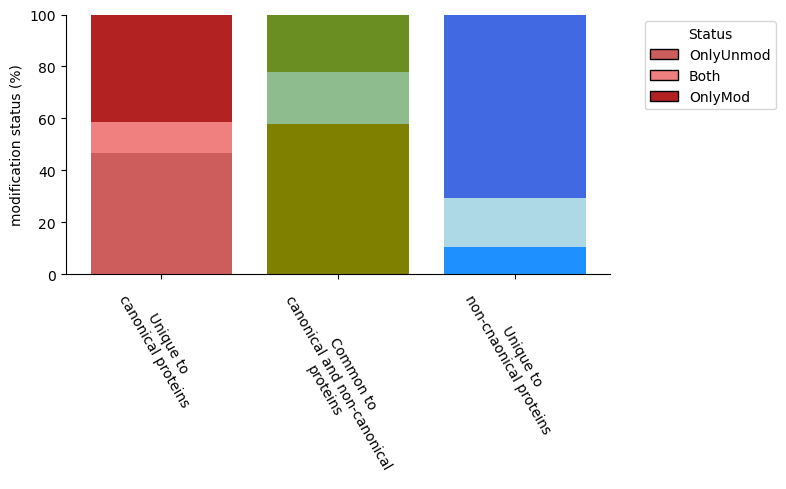

In [73]:
order = ['OnlyUnmod', 'Both', 'OnlyMod']

# Pivot data
height_df = pep_mod_rate.pivot(index='cat', columns='status', values='percent')[order]
count_df = pep_mod_rate.pivot(index='cat', columns='status', values='count')[order]

# Define colors per 'cat'
#cat_colors = {
#    'Canonical': ['#6baed6', '#9ecae1', '#c6dbef'],   # blue shades
#    'Common': ['#74c476', '#a1d99b', '#c7e9c0'],      # green shades
#    'NonCanonical': ['#fd8d3c', '#fdae6b', '#fdd0a2'] # orange shades
#}
cat_colors = {
    'Canonical' : [project_palette2[f"ionbot_canon_unique_{_}"] for _ in order],
    'Common' : [project_palette2[f"ionbot_shared_{_}"] for _ in order],
    'NonCanonical' : [project_palette2[f"ionbot_noncanon_unique_{_}"] for _ in order],
}

fig, ax = plt.subplots(figsize=(8, 5))

# Draw bars manually per cat
bar_positions = range(len(height_df))
bar_width = 0.8

for i, cat in enumerate(height_df.index):
    bottom = 0
    colors = cat_colors.get(cat, ['gray']*len(order))
    for j, status in enumerate(order):
        height = height_df.loc[cat, status]
        count = count_df.loc[cat, status]
        ax.bar(
            i, height, width=bar_width,
            bottom=bottom, color=colors[j],
        )
        #if height > 0:
        #    ax.text(
        #        i, bottom + height / 2, f"{int(count)}",
        #        ha='center', va='center',
        #        color='white', fontsize=9, fontweight='bold'
        #    )
        bottom += height

# Format
ax.set_xticks(bar_positions)
ax.set_xticklabels(height_df.index)
ax.set_xticks([0,1,2],['Unique to\ncanonical proteins','Common to\ncanonical and non-canonical\nproteins','Unique to\nnon-cnaonical proteins'], rotation=300)
ax.set_ylabel("modification status (%)")
ax.set_ylim(0, 100)
sns.despine()

# Custom legend showing status order
from matplotlib.patches import Patch
# --- Build legend with all category–status combinations ---
legend_handles = []
legend_labels = []
for cat, colors in cat_colors.items():
    for status, color in zip(order, colors):
        legend_handles.append(Patch(facecolor=color, edgecolor='black'))
        legend_labels.append(f"{cat} – {status}")

# Add the legend
ax.legend(
    legend_handles,
    legend_labels,
    title="Category – Status",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=True
)

plt.legend(legend_handles, order, title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig(f"{plot_dir}/{PIPELINE_LW}_mod_pep.svg", format='svg', bbox_inches = 'tight')

### Protein modification rate

In [74]:
# reduce to infered proteins
print('Before explode:', len(psmpep_filt_op))
psmpep_filt_op['proteins_explode'] = psmpep_filt_op['proteins']
psmprot_filt_op = psmpep_filt_op.explode('proteins_explode').reset_index(drop=True)
print('After explode:', len(psmprot_filt_op))
psmprot_filt_op = psmprot_filt_op[psmprot_filt_op['proteins_explode'].isin(prot_filt_op['proteins'].tolist())]
print('Inferred proteins:', len(psmprot_filt_op))

Before explode: 313941
After explode: 3123747
Inferred proteins: 2254575


In [75]:
prot_mod_rate = []
for isCanonical, df in psmprot_filt_op.groupby('isCanonical'):
    # Count how many peptides per group are 'Unmodified'
    counts = (
        df.assign(is_unmod=df['isModified'].eq('Unmodified'))
          .groupby('database_peptide')['is_unmod']
          .agg(['sum', 'count'])
    ) # sum - N of PSMs / count - N of Unmodified
    counts['status'] = counts.apply(classify, axis=1)
    # annotate with proteins (including groups)
    counts_prot = counts.merge(pep_filt_op[['database_peptide','proteins']], how='inner', on='database_peptide')
    # fraction of peptides modified at least once
    result1 = counts_prot.groupby('proteins').apply(lambda x: 1 - (Counter(x['status'])['OnlyUnmod'])/len(x) ).to_frame().reset_index()
    result1.columns = ['proteins','mod']
    # with how many peptides protein was identified
    #result2 = counts_prot.groupby('proteins').apply(len).to_frame().reset_index(drop=True)
    #result2.columns = ['n_pep']
    # was protein identified with 1 peptide
    result2 = counts_prot.groupby('proteins').apply(lambda x: len(x)==1).to_frame().reset_index(drop=True)
    result2.columns = ['isOne']
    result = pd.concat([result1,result2],axis=1)
    result['isCanonical'] = isCanonical
    prot_mod_rate += [result]
prot_mod_rate = pd.concat(prot_mod_rate)

/tmp/ipykernel_3845330/1709390878.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result1 = counts_prot.groupby('proteins').apply(lambda x: 1 - (Counter(x['status'])['OnlyUnmod'])/len(x) ).to_frame().reset_index()
/tmp/ipykernel_3845330/1709390878.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result2 = counts_prot.groupby('proteins').apply(lambda x: len(x)==1).to_frame().reset_index(drop=True)
/

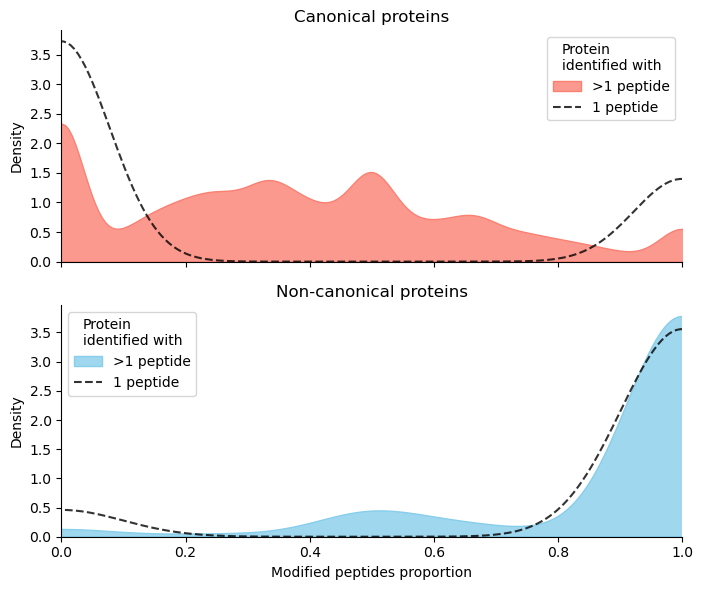

In [76]:
unique_cats = prot_mod_rate['isCanonical'].unique()
fig, axes = plt.subplots(
    nrows=len(unique_cats), ncols=1,
    sharex=True,
    figsize=(7, 3 * len(unique_cats))
)

# Ensure axes is iterable
if len(unique_cats) == 1:
    axes = [axes]

for ax, (isCanonical, df1) in zip(axes, prot_mod_rate.groupby('isCanonical')):
    color= "ionbot_noncanon_unique" if isCanonical=='NonCanonical' else "ionbot_canon_unique"
    for isOne, df2 in df1.groupby('isOne'):
        sns.kdeplot(
            data=df2, x='mod',
            fill=not isOne,
            linestyle='--' if isOne else '-',
            ax=ax,
            label= '1 peptide' if isOne else '>1 peptide',
            cut=True,
            color='black' if isOne else project_palette2[color], alpha=0.8
        )
    ax.set_title(f"{'Non-canonical proteins' if isCanonical=='NonCanonical' else  'Canonical proteins'}")
    ax.legend(title="Protein\nidentified with")
    ax.set_xlim((0,1))
    ax.set_xlabel('Modified peptides proportion')
    sns.despine(ax=ax)

plt.tight_layout()

plt.savefig(f"{plot_dir}/{PIPELINE_LW}_mod_pep_per_prot.svg", format='svg', bbox_inches = 'tight')

/tmp/ipykernel_3845330/1759587111.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['slice'] = df['isCanonical'].map({'NonCanonical': 'Non-canonical proteins\n', 'Canonical': 'Canonical proteins\n'}).astype(str) + ' with ' + df['isOne'].map({True: '1 peptide', False: '>1 peptide'})


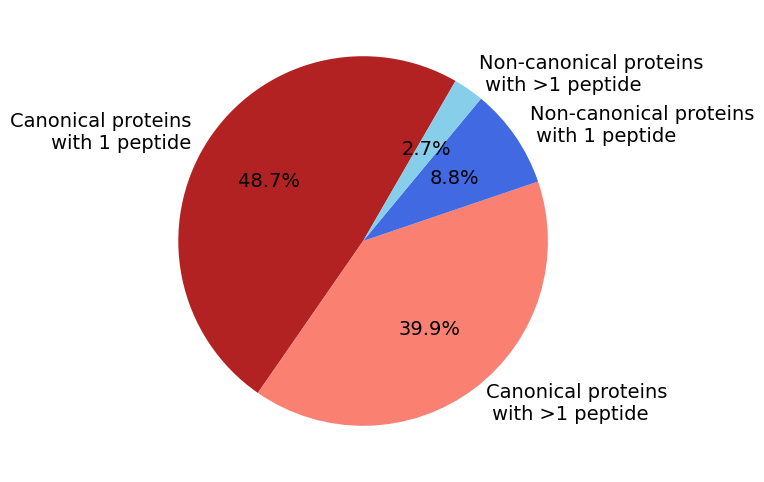

In [77]:
df = prot_mod_rate[prot_mod_rate['mod'] == 1]

# Create a combined category for slicing
df['slice'] = df['isCanonical'].map({'NonCanonical': 'Non-canonical proteins\n', 'Canonical': 'Canonical proteins\n'}).astype(str) + ' with ' + df['isOne'].map({True: '1 peptide', False: '>1 peptide'})

# Count occurrences for each slice
slice_counts = df['slice'].value_counts()

# Define colors manually (optional)
#colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']  # 4 slices (adjust if needed)
attributes=["ionbot_canon_unique_OnlyMod","ionbot_canon_unique","ionbot_noncanon_unique_OnlyMod","ionbot_noncanon_unique",]

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    slice_counts,
    labels=slice_counts.index,
    autopct='%1.1f%%',
    startangle=60,
    colors=[project_palette2[at] for at in attributes],
    textprops={'fontsize': 14},
)

plt.savefig(f"{plot_dir}/{PIPELINE_LW}_only_mod_prot.svg", format='svg', bbox_inches = 'tight')

### Map PTMs to mass-shifts

#### Load unimod

In [78]:
from Download_UnimodDB import *

In [79]:
def PTM_string_to_masses_list(ptm_string, unimod):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    x = {a:re.split('[][]',b) for a,b in x}
    x = [(int(a),b[3],int(b[1])) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod)) for a,b,c in x]    
    return x
#Modify to parce 9999 not by unimod_id but by code_name
def PTM_string_to_masses_list_9999(ptm_string, unimod, unimod_df):
    if ptm_string=='Unmodified':
        return 'Unmodified'
    # if a peptide has 2 or more possible modified forms, take only 1
    #print(ptm_string)
    x = ptm_string.split('_or_')[0]
    x = x.split('||')
    x = [_.split('|') for _ in x]
    #print(x)
    x = {a:re.split('[][]',b) for a,b in x}
    #print(x)
    x = [(int(a),b[3],int(b[1]) if "9999" not in b[1] else b[2]) for a,b in x.items()]
    x = [(a,b,getPTMmass(c,unimod) if not isinstance(c,str) 
          else float(unimod_df[unimod_df.code_name==c].mono_mass.iloc[0]) if c in unimod_df.code_name.tolist()
         else np.nan) for a,b,c in x]    
    return x

In [80]:
def Download_Unimod_Dict_names():
    unimod = Download_UnimodDB()
    condensed_unimod = {}
    for uni_id,df in unimod.groupby("unimod_id").__iter__():
        condensed_unimod[uni_id] = {}
        condensed_unimod[uni_id]['residues'] = "".join([_ for _ in df.residue if '-' not in _])
        condensed_unimod[uni_id]['mono_mass'] = [_ for _ in set(df.mono_mass)][0]
        condensed_unimod[uni_id]['code_name'] = [_ for _ in set(df.code_name)][0]
        condensed_unimod[uni_id]['full_name'] = [_ for _ in set(df.full_name)][0]
        condensed_unimod[uni_id]['classification'] = [_ for _ in set(df.classification)][0]
        
    return condensed_unimod

In [81]:
unimod = Download_Unimod_Dict_names()
unimod_df=pd.DataFrame.from_dict(unimod, orient='index')

In [82]:
#how many modifications are detected on all aa
unimod_df_massgroups=unimod_df.groupby("mono_mass")
massgr_aall=unimod_df_massgroups.apply(lambda x: len(set("".join(x.residues.tolist()))))
a=massgr_aall.value_counts()
a[[1,2,3]].sum()/a.sum()

/tmp/ipykernel_3845330/28356429.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  massgr_aall=unimod_df_massgroups.apply(lambda x: len(set("".join(x.residues.tolist()))))


np.float64(0.9165477888730386)

In [83]:
#mark substitutions
unimod_df["isSubstitution"]=unimod_df.full_name.apply(lambda x: "substitution" in x)
unimod_df_subs=unimod_df[unimod_df["isSubstitution"]]

#### Annnotate modifications with mass shifts (PSM)

In [84]:
# PSM level

# to remove retention times in parentheses
#psm_filt['modifications_noRT'] = psm_filt.modifications.str.replace(re.compile(r'.+?.+?'), '', regex=True)
psm_filt['modifications_noRT'] = psm_filt.modifications.str.replace(r'[)]∗[^)]*', '', regex=True)
# correct where possible unimod ids
psm_filt['modifications_masses'] = psm_filt.modifications.apply(lambda x: PTM_string_to_masses_list_9999(x,unimod,unimod_df))
# parce several modifications and map mass
psm_filt['masses'] =  psm_filt.modifications_masses.apply(lambda x: [0] if x=='Unmodified' else [mod[2] for mod in x])
# get sum of modifications mass
psm_filt['tot_mass_shift'] = psm_filt.modifications_masses.apply(lambda x: 0 if x=='Unmodified' else np.sum([mod[2] for mod in x]))
psm_filt['tot_mass_shift'] = psm_filt['tot_mass_shift'].fillna(0) #NAs are from 999
#check that residues of mono_mass substitution and residues in peptide overlap
psm_filt["isSubstitution"]=psm_filt.apply(lambda x: any([False if i not in unimod_df_subs.mono_mass.tolist() else 
                                                     any(r in x["database_peptide"] for r in unimod_df_subs[unimod_df_subs.mono_mass==i].residues.tolist())
                                                      for i in x["masses"]]),axis=1)
# unimod ptm classification
psm_filt["masses_classification"]=psm_filt.apply(lambda x: [ unimod_df[unimod_df.mono_mass==i].classification.tolist() for i in x["masses"]],axis=1)

In [85]:
psm_filt[['modifications','modifications_noRT', 'modifications_masses', 'masses', 'tot_mass_shift', "isSubstitution", "masses_classification"]].head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,modifications,modifications_noRT,modifications_masses,masses,tot_mass_shift,isSubstitution,masses_classification
0,19|[35]Hydroxylation[M],19|[35]Hydroxylation[M],"[(19, M, 15.9949)]",[15.9949],15.9949,True,"[[Multiple, AA substitution, AA substitution]]"
1,9|[4]Carbamidomethyl[C],9|[4]Carbamidomethyl[C],"[(9, C, 57.0215)]",[57.0215],57.0215,True,"[[Chemical derivative, Chemical derivative, AA..."
2,10|[35]Hydroxylation[M],10|[35]Hydroxylation[M],"[(10, M, 15.9949)]",[15.9949],15.9949,True,"[[Multiple, AA substitution, AA substitution]]"
3,16|[35]Hydroxylation[M],16|[35]Hydroxylation[M],"[(16, M, 15.9949)]",[15.9949],15.9949,True,"[[Multiple, AA substitution, AA substitution]]"
4,15|[35]Hydroxylation[M],15|[35]Hydroxylation[M],"[(15, M, 15.9949)]",[15.9949],15.9949,True,"[[Multiple, AA substitution, AA substitution]]"


#### Total mass shift distribution (peptidophorm)

In [86]:
# indicate peptides common between protein classes
psm_filt['isCommon'] = psm_filt['peptide_class'].str.contains('shared')
psm_filt['isCommon'] = psm_filt.apply(lambda x: 'Common' if x['isCommon'] else x['isCanonical'] ,axis=1)

In [87]:
pepphorm_filt_op = psm_filt[psm_filt['search_database'] == 'openprot']
print('All OP psm', len(pepphorm_filt_op))
pepphorm_filt_op = pepphorm_filt_op[pepphorm_filt_op['database_peptide'].isin(pep_filt[pep_filt['search_database'] == 'openprot']['database_peptide'].tolist())]
print('Peptide-level psm', len(pepphorm_filt_op))
pepphorm_filt_op = pepphorm_filt_op.drop_duplicates(['database_peptide','modifications_noRT'])
print('Peptidophorm', len(pepphorm_filt_op))

All OP psm 323529
Peptide-level psm 313941
Peptidophorm 109807


/tmp/ipykernel_3845330/2340479003.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=["Unique to a \ncanonical \nprotein",


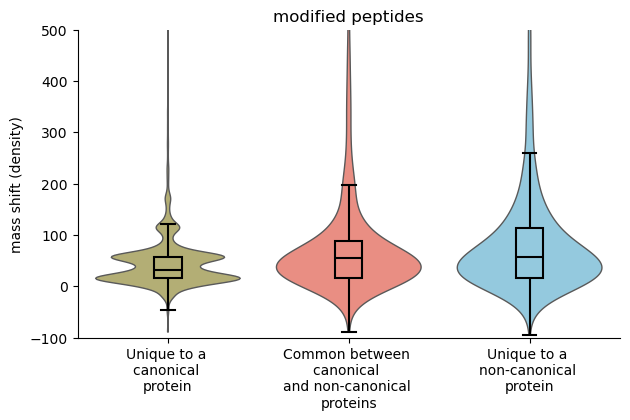

In [88]:
fig, ax = plt.subplots(1,1,figsize=(7,4))
# take only modified
data=pepphorm_filt_op[(pepphorm_filt_op.tot_mass_shift!=0)].reset_index(drop=True)
sns.violinplot(x="isCommon",y="tot_mass_shift",data=data,ax=ax, inner=None,linewidth=1,
              palette={"Canonical": project_palette2[f"ionbot_canon_unique"], 
                       "NonCanonical": project_palette2[f"ionbot_noncanon_unique"],
                      "Common":project_palette2[f"ionbot_shared"]},
               gridsize=1000,cut=0
              );
sns.boxplot(x="isCommon",y="tot_mass_shift",data=data,ax=ax,
                width=0.15,  # Keeps boxplot thin
                dodge=False,
                boxprops={"facecolor": "none", "edgecolor": "black", "linewidth": 1.5},  # Thinner box edges
                whiskerprops={"color": "black", "linewidth": 1.5},  # Thinner whiskers
                capprops={"color": "black", "linewidth": 1.5},  # Thinner caps
                medianprops={"color": "black", "linewidth": 1.5},  # Thinner dashed median line
                showfliers=False,  # Hide outliers
);
ax.set_ylim(-100,500)
ax.set_title("modified peptides");
ax.set_ylabel("mass shift (density)");
ax.set_xlabel("");
ax.set_xticklabels(labels=["Unique to a \ncanonical \nprotein",
                            "Common between \ncanonical \nand non-canonical \nproteins",
                           "Unique to a \nnon-canonical \nprotein"],fontsize=10);
sns.despine()

plt.savefig(f"{plot_dir}/{PIPELINE_LW}_tot_mod.svg", format='svg', bbox_inches = 'tight')

In [89]:
# marginal total mass shifts
print(pepphorm_filt_op.groupby('isCommon')['tot_mass_shift'].apply(max))
print(pepphorm_filt_op.groupby('isCommon')['tot_mass_shift'].apply(min))

isCommon
Canonical       1806.6300
Common          2044.7353
NonCanonical    1305.4164
Name: tot_mass_shift, dtype: float64
isCommon
Canonical      -89.0299
Common         -89.0299
NonCanonical   -94.0419
Name: tot_mass_shift, dtype: float64


#### Top frequent modifications (peptidophorm)

In [90]:
from functools import reduce

In [91]:
mod_frq = []
### take only modified [(pepphorm_filt_op.tot_mass_shift!=0)]
for isCommon, df in pepphorm_filt_op.groupby('isCommon'):
    # concider individual modifications, not combinations
    df = df.explode('masses')
    # consider unique modifications per peptide
    df = df.drop_duplicates(['database_peptide','masses'])
    # count the most frequent masses in category, normalise by number of peptides
    frq = (df.masses.value_counts()/len(df)).to_frame().sort_values('count',ascending=False).reset_index()
    frq['isCommon'] = isCommon
    mod_frq += [frq.head(15)] # top 15
# merge
mod_frq = reduce(lambda left, right: pd.merge(left, right, on='masses', how='outer', ), mod_frq).rename(
    columns={'count_x':'count_Canonical','count_y':'count_Common','count':'count_NonCanonical'}
).drop(['isCommon_x','isCommon_y','isCommon'],axis=1).fillna(0)

In [92]:
# sum frequencies btw categories, sort 
mod_frq['sum_of_cols'] = mod_frq['count_Canonical'] + mod_frq['count_Common'] + mod_frq['count_NonCanonical']
mod_frq_sorted = mod_frq.sort_values(by='sum_of_cols', ascending=False)
mod_frq_sorted = mod_frq_sorted.drop(columns=['sum_of_cols'])
mod_frq_sorted = mod_frq_sorted.set_index('masses')

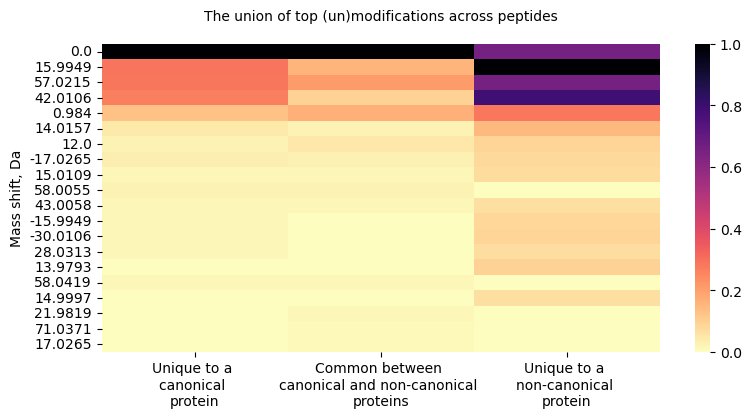

In [93]:
# %
data = mod_frq_sorted*100
# normalise by columns - devide on max
data = data / data.max()

fig, axes = plt.subplots(1,1,figsize=(9,4));
sns.heatmap(data, ax=axes,cmap = "magma_r",vmin=0)#,cbar_kws={'label': 'frequency'})
axes.set_ylabel('Mass shift, Da')
axes.set_title('The union of top (un)modifications across peptides',fontsize=10,y=1.05)
axes.set_xticklabels(labels=["Unique to a \ncanonical \nprotein",
                            "Common between \ncanonical and non-canonical \nproteins",
                           "Unique to a \nnon-canonical \nprotein"],fontsize=10);

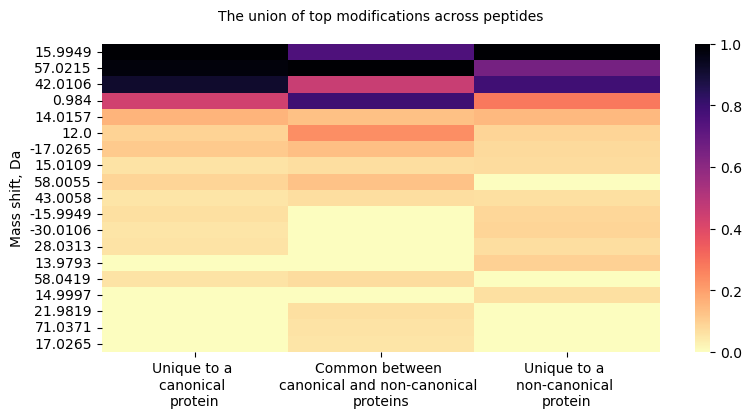

In [94]:
# %
data = mod_frq_sorted*100
# remove unmodified
data = data.iloc[1:]
# normalise by columns - devide on max
data = data / data.max()
# save
data.to_pickle(f'{root}/oui-discovery-vv-data/pickles/ionbot_open_all_pepphorm_mod.pkl')

fig, axes = plt.subplots(1,1,figsize=(9,4));
sns.heatmap(data, ax=axes,cmap = "magma_r",vmin=0)#,cbar_kws={'label': 'frequency'})
axes.set_ylabel('Mass shift, Da')
axes.set_title('The union of top modifications across peptides',fontsize=10,y=1.05)
axes.set_xticklabels(labels=["Unique to a \ncanonical \nprotein",
                            "Common between \ncanonical and non-canonical \nproteins",
                           "Unique to a \nnon-canonical \nprotein"],fontsize=10);

plt.savefig(f"{plot_dir}/{PIPELINE_LW}_all_pepphorm_mod.svg", format='svg', bbox_inches = 'tight')

#### Top frequent modifications by proteotypic peptide localization (peptidophorm)

In [95]:
#get the peptides' positions in proteins

count_var=0
pepphorm_uniq_filt_op = pepphorm_filt_op[pepphorm_filt_op['isProteotypic'] == True].reset_index(drop=True)
pepphorm_uniq_filt_op["peptide_position"]='nan'
for i,row in pepphorm_uniq_filt_op.iterrows():
    peptide=row["database_peptide"]; prot=row["proteins"][0]
    prot_seq=str(OPfasta[prot].seq)
    pos=hpp.get_pep_positions(prot_seq,peptide)
    if len(pos)>1: pos=[pos[0]] #take first occurance in protein
    if len(pos)==0: #if didnt find peptide in protein
        # try L->I
        peptide = peptide.replace('L','I')
        prot_seq=str(OPfasta[prot].seq)
        pos=hpp.get_pep_positions(prot_seq,peptide)
        if len(pos)>1: pos=[pos[0]]
        if len(pos)==0:
            count_var+=1;  pos=[np.nan]
            print(peptide,prot,prot_seq)
    pepphorm_uniq_filt_op.at[i,"peptide_position"]=[[pos[0]]]#pd.Series([pos[0]]).values[0]
#are their peptides with SAAVs introduced 
print(count_var)
#drop peptides with SAAVs introduced by Comet
pepphorm_uniq_filt_op=pepphorm_uniq_filt_op[~pepphorm_uniq_filt_op.peptide_position.isna()]

0


In [96]:
# mark N-terminal (True) and internal (false) peptides, concidering M-clip

pepphorm_uniq_filt_op['isNterm'] = pepphorm_uniq_filt_op['peptide_position'].apply(lambda x: x[0][0][0]<2)

In [97]:
mod_frq_pos = []
# take (un)modified - togather
for isCommon, df in pepphorm_uniq_filt_op.groupby('isCommon'):
    if isCommon == 'Common': continue
    # concider individual modifications, not combinations
    df = df.explode('masses')
    # consider unique modifications per peptide
    df = df.drop_duplicates(['database_peptide','masses'])
    # count the most frequent masses in category, normalise by number of peptides
    frq = (df.masses.value_counts()/len(df)).to_frame().sort_values('count',ascending=False).reset_index()
    frq['isCommon'] = isCommon
    mod_frq_pos += [frq]
# take (un)modified - by peptide type
for (isCommon, isNterm), df in pepphorm_uniq_filt_op.groupby(['isCommon','isNterm']):
    if isCommon == 'Common': continue
    # concider individual modifications, not combinations
    df = df.explode('masses')
    # consider unique modifications per peptide
    df = df.drop_duplicates(['database_peptide','masses'])
    # count the most frequent masses in category, normalise by number of peptides
    frq = (df.masses.value_counts()/len(df)).to_frame().sort_values('count',ascending=False).reset_index()
    frq['isCommon_isNterm'] = isCommon + '_' + ('Nterm' if isNterm else 'internal')
    mod_frq_pos += [frq.head(15)]

# merge
mod_frq_pos = reduce(
        lambda left, right: pd.merge(
            left, right,
            on='masses',
            how='outer',
            suffixes=('', f'_{len(left.columns)}')  # unique per merge
        ),
        mod_frq_pos
    ).rename(
        columns={'count':'count_Canonical_all','count_3':'count_NonCanonical_all','count_5':'count_Canonical_internal',
                'count_7':'count_Canonical_Nterm','count_9':'count_NonCanonical_internal', 'count_11':'count_NonCanonical_Nterm'
                }
    ).drop(['isCommon','isCommon_3','isCommon_isNterm','isCommon_isNterm_7','isCommon_isNterm_9','isCommon_isNterm_11'],axis=1).fillna(0).set_index('masses')
# rearrange columns
mod_frq_pos = mod_frq_pos[['count_Canonical_all','count_Canonical_Nterm','count_Canonical_internal',
                          'count_NonCanonical_all','count_NonCanonical_Nterm','count_NonCanonical_internal',]]

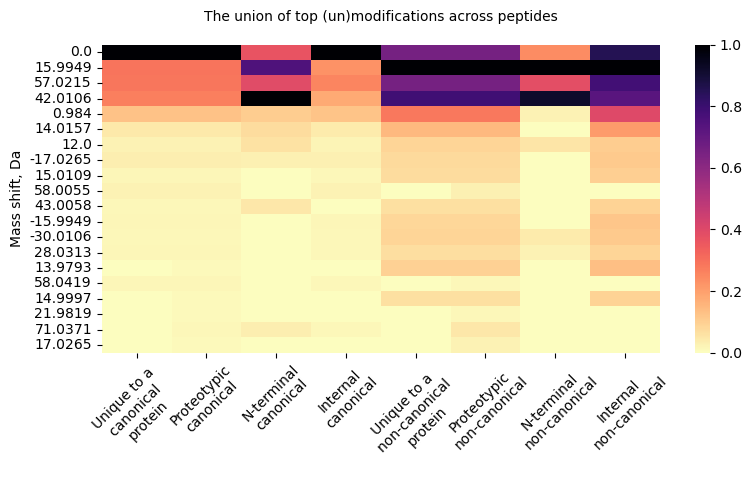

In [98]:
# order as in all peptides (including non-proteotypic)
data = mod_frq_pos.loc[mod_frq_sorted.index] *100
data2 = data.merge(mod_frq_sorted*100,on='masses')
data2 = data2[['count_Canonical','count_Canonical_all','count_Canonical_Nterm','count_Canonical_internal',
                'count_NonCanonical','count_NonCanonical_all','count_NonCanonical_Nterm','count_NonCanonical_internal']]
# normalise by columns - devide on max
data2 = data2 / data2.max()
fig, axes = plt.subplots(1,1,figsize=(9,4));
sns.heatmap(data2, ax=axes,cmap = "magma_r",vmin=0)#,cbar_kws={'label': 'frequency'})
axes.set_ylabel('Mass shift, Da')
axes.set_title('The union of top (un)modifications across peptides',fontsize=10,y=1.05)
axes.set_xticklabels(labels=["Unique to a \ncanonical \nprotein", 'Proteotypic\ncanonical','N-terminal\ncanonical','Internal\ncanonical',
                            "Unique to a \nnon-canonical \nprotein", 'Proteotypic\nnon-canonical','N-terminal\nnon-canonical','Internal\nnon-canonical'],
                     fontsize=10, rotation=45);

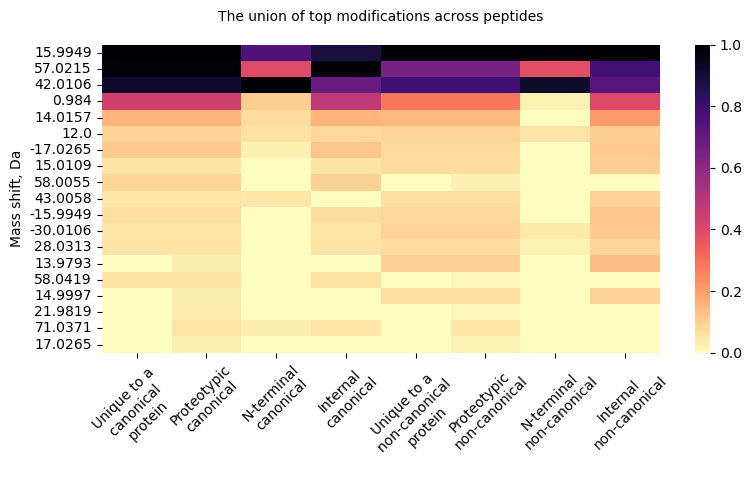

In [99]:
# order as in all peptides (including non-proteotypic)
data = mod_frq_pos.loc[mod_frq_sorted.index] *100
data2 = data.merge(mod_frq_sorted*100,on='masses')
data2 = data2[['count_Canonical','count_Canonical_all','count_Canonical_Nterm','count_Canonical_internal',
                'count_NonCanonical','count_NonCanonical_all','count_NonCanonical_Nterm','count_NonCanonical_internal']]
# remove unmodified
data2 = data2.iloc[1:]
# normalise by columns - devide on max
data2 = data2 / data2.max()

fig, axes = plt.subplots(1,1,figsize=(9,4));
sns.heatmap(data2, ax=axes,cmap = "magma_r",vmin=0)#,cbar_kws={'label': 'frequency'})
axes.set_ylabel('Mass shift, Da')
axes.set_title('The union of top modifications across peptides',fontsize=10,y=1.05)
axes.set_xticklabels(labels=["Unique to a \ncanonical \nprotein", 'Proteotypic\ncanonical','N-terminal\ncanonical','Internal\ncanonical',
                            "Unique to a \nnon-canonical \nprotein", 'Proteotypic\nnon-canonical','N-terminal\nnon-canonical','Internal\nnon-canonical'],
                     fontsize=10, rotation=45);

plt.savefig(f"{plot_dir}/{PIPELINE_LW}_bypos_pepphorm_mod.svg", format='svg', bbox_inches = 'tight')

In [100]:
### Do N-term proteotypic peptides tend to be modified (Unexpected) more often than internal by peptide class

In [101]:
mod_frq_nterm = []
# take only modified isModified_isAcet
for (isCommon, isNterm), df in pepphorm_uniq_filt_op.groupby(['isCommon','isNterm']):
    if isCommon == 'Common': continue
    # unmodified and expected - same
    df['isModified'] = df['isModified'].map({"Unmodified":"Unmodified/Expected","Expected":"Unmodified/Expected","Unexpected":"Unexpected"})
    # count the most frequent masses in category, normalise by number of peptides
    frq = (df['isModified'].value_counts()/len(df)).to_frame().sort_values('count',ascending=False).reset_index()
    frq['isCommon_isNterm'] = isCommon + '_' + ('Nterm' if isNterm else 'internal')
    mod_frq_nterm += [frq]
mod_frq_nterm = pd.concat(mod_frq_nterm)
mod_frq_nterm['count'] *= 100

In [102]:
# it is slightly true for canonical (internal equaly Unexpected mod, but Ntern enreached in them)
# but for noncanonical - oposit (N-term equaly Unexpected mod, but internal enreached in them)
# so, mb, N-tem pep aboundance for non-canonical class is more related to factual N-term noncanon peptide aboundance? - this is in lign with database digestion
mod_frq_nterm

,isModified,count,isCommon_isNterm
0,Unexpected,58.230834,Canonical_internal
1,Unmodified/Expected,41.769166,Canonical_internal
0,Unexpected,66.787659,Canonical_Nterm
1,Unmodified/Expected,33.212341,Canonical_Nterm
0,Unexpected,80.734406,NonCanonical_internal
1,Unmodified/Expected,19.265594,NonCanonical_internal
0,Unmodified/Expected,54.210526,NonCanonical_Nterm
1,Unexpected,45.789474,NonCanonical_Nterm


In [103]:
### N-terminal modifications (N-term acetylation) co-occure with unexpected or more N-term peptide recovered due to only unexpected mod?

In [104]:
# number of N-term proteotypic peptides by class with Acetyl+Unexpected and only unexpected peptides

In [105]:
nterm_acet = 42.0106
mod_frq_acet = []
# take only modified isModified_isAcet
for (isCommon, isNterm), df in pepphorm_uniq_filt_op.groupby(['isCommon','isNterm']):
    if isCommon == 'Common': continue
    # mark types
    df['isAcet'] = df['masses'].apply(lambda x: nterm_acet in x )
    df['isModified_isAcet'] = df['isModified'] + '_' + df['isAcet'].astype(str)
    # not interested in this
    #df = df[df['isModified_isAcet']!='Expected_False']
    # count the most frequent masses in category, normalise by number of peptides
    frq = (df.isModified_isAcet.value_counts()/len(df)).to_frame().sort_values('count',ascending=False).reset_index()
    frq['isCommon_isNterm'] = isCommon + '_' + ('Nterm' if isNterm else 'internal')
    mod_frq_acet += [frq]
mod_frq_acet = pd.concat(mod_frq_acet)
mod_frq_acet['count'] *= 100

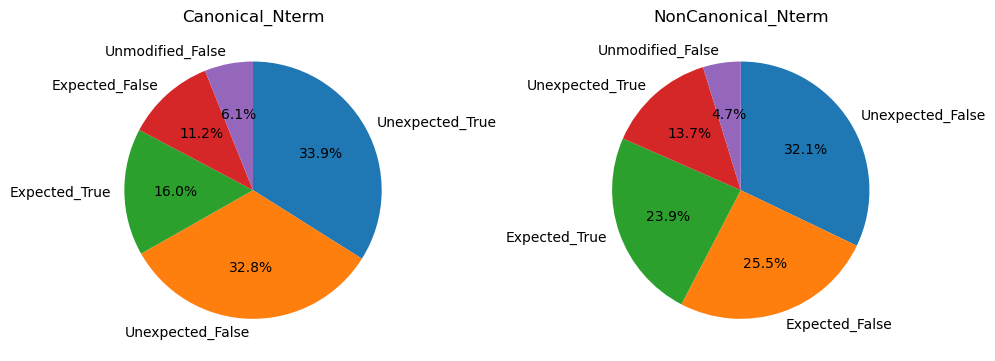

In [106]:
# only Acet - Expected_True
# only Unexpected - Unexpected_False
# both - Unexpected_True

# so both Acetyl+Unexpected and only Unexpected play a role 

data = mod_frq_acet[mod_frq_acet['isCommon_isNterm'].str.contains('Nterm')]

# Get unique groups (for two pie charts)
groups = data['isCommon_isNterm'].unique()

# Create subplots (two side-by-side pies)
fig, axes = plt.subplots(1, len(groups), figsize=(10, 5))

# In case there’s only one group
if len(groups) == 1:
    axes = [axes]

# Plot each pie
for ax, group in zip(axes, groups):
    subset = data[data['isCommon_isNterm'] == group]
    ax.pie(
        subset['count'],
        labels=subset['isModified_isAcet'],
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False
    )
    ax.set_title(group)

plt.tight_layout()
plt.show()

#### Total mass shift distribution by proteotypic peptide localisation (PSM)